# Module 1 — Dataset Simulation & Backward-Only Sliding-Window Feature Extraction

**PhD Methodology 1 (M1):** *A Leakage-Aware XGBoost Framework with Sliding-Window Feature Extraction for Robust Failure Precursor Detection in Large-Scale Data Centers*

This notebook implements the first two components of the M1 pipeline:

1. **Synthetic data-center telemetry simulation** — a stand-in for the harmonized Google / Alibaba / Azure traces (Section 4.2 of the paper), used here to develop and unit-test the pipeline logic before it is pointed at real trace data. The simulator produces multi-machine, multi-variate telemetry (CPU utilization, memory usage, disk I/O rate, scheduling latency) with realistic pre-failure degradation patterns and injected failure events.
2. **Backward-only, multi-scale sliding-window feature extraction** (Section 4.3 of the paper) — rolling mean, rolling standard deviation, first-difference trend, and coefficient-of-variation (volatility) features computed strictly over `[t-W+1, t]`, at window scales `W ∈ {5, 15, 60}`, together with a programmatic **leakage boundary check** that verifies no feature uses information beyond its own row's timestamp.

**Scope note:** consistent with the four-stage PhD methodology arc, this module deliberately stops at feature extraction. Forward-horizon failure labeling, chronological splitting, XGBoost training, and the full leakage-audit module are separate downstream modules and are **not** implemented here, so that each module can be reviewed and tested independently.

**Out of scope for M1 (reserved for later methodologies):** LSTM/GRU/Transformer sequence models, graph neural networks, reinforcement learning, and explainability layers are not used anywhere in this notebook.


## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Dict

pd.set_option("display.max_columns", 20)


In [4]:
pd.set_option("display.width", 140)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 4)


## 2. Configuration

All simulation and feature-extraction parameters are declared in one place so the notebook is easy to re-run with different scales. `WINDOW_SIZES` matches the three-scale design used in the M1 paper (`W ∈ {5, 15, 60}` sampling intervals, capturing short-, medium-, and longer-horizon precursor behavior).

In [5]:
@dataclass
class SimConfig:
    n_machines: int = 25            # number of simulated machines/tasks
    n_timestamps: int = 2000        # length of the trace, in sampling intervals
    sampling_interval_minutes: int = 5   # native sampling interval (minutes)
    n_failures_per_machine: tuple = (0, 3)  # min/max failure events per machine
    precursor_window: int = 60      # how many timesteps before a failure degradation begins
    noise_std: float = 2.5          # baseline telemetry noise
    telemetry_cols: tuple = ("cpu_util", "mem_util", "disk_io", "sched_latency")

@dataclass
class FeatureConfig:
    window_sizes: tuple = (5, 15, 60)   # backward-only window scales, matches Section 4.3
    epsilon: float = 1e-6               # prevents division by zero in CV feature
    min_periods_policy: str = "strict"  # "strict" -> drop rows with < W prior samples

sim_cfg = SimConfig()
feat_cfg = FeatureConfig()
sim_cfg, feat_cfg


(SimConfig(n_machines=25, n_timestamps=2000, sampling_interval_minutes=5, n_failures_per_machine=(0, 3), precursor_window=60, noise_std=2.5, telemetry_cols=('cpu_util', 'mem_util', 'disk_io', 'sched_latency')),
 FeatureConfig(window_sizes=(5, 15, 60), epsilon=1e-06, min_periods_policy='strict'))

## 3. Dataset Simulation

The simulator is intentionally schema-shaped like a harmonized data-center trace (`machine_id`, `timestamp`, telemetry columns, `failure_event`), so downstream modules built against it will also work against a real harmonized Google/Alibaba/Azure extract (Section 4.2) without modification.

Design choices, matched to real precursor-detection behavior:

- Each telemetry stream follows a mean-reverting random walk (baseline "healthy" behavior).
- A random number of failure events (0–3) is assigned per machine, spaced out along the trace.
- In the `precursor_window` timesteps immediately before each failure, telemetry drifts upward (CPU/memory/disk/latency all trend toward saturation) and becomes noisier — this is what a leakage-safe feature extractor is meant to detect using only backward-looking information.
- The exact failure timestamp is flagged in a binary `failure_event` column. This column is carried through for use by a **later** labeling module (forward-horizon labeling is out of scope here — see the scope note in Section 1).


In [7]:
def simulate_machine_trace(machine_id: int, cfg: SimConfig, rng: np.random.Generator) -> pd.DataFrame:
    T = cfg.n_timestamps
    timestamps = pd.date_range("2026-01-01", periods=T, freq=f"{cfg.sampling_interval_minutes}min")

    # baseline mean-reverting random walk per telemetry stream, independent base levels
    base_levels = {"cpu_util": 35, "mem_util": 45, "disk_io": 20, "sched_latency": 15}
    series = {}
    for col in cfg.telemetry_cols:
        x = np.zeros(T)
        x[0] = base_levels[col] + rng.normal(0, cfg.noise_std)
        theta = 0.05  # mean-reversion strength
        for t in range(1, T):
            x[t] = x[t - 1] + theta * (base_levels[col] - x[t - 1]) + rng.normal(0, cfg.noise_std)
        series[col] = x

    # assign failure events
    n_failures = rng.integers(cfg.n_failures_per_machine[0], cfg.n_failures_per_machine[1] + 1)
    failure_idx = []
    if n_failures > 0:
        # keep failures spaced apart and away from the very start of the trace
        candidates = rng.choice(
            np.arange(cfg.precursor_window + 10, T - 5),
            size=min(n_failures, T // (cfg.precursor_window + 20)),
            replace=False,
        )
        failure_idx = sorted(candidates.tolist())

    failure_event = np.zeros(T, dtype=int)
    for f_idx in failure_idx:
        failure_event[f_idx] = 1
        # inject pre-failure degradation: upward drift + increasing noise over the precursor window
        start = max(0, f_idx - cfg.precursor_window)
        ramp = np.linspace(0, 1, f_idx - start) ** 1.5  # accelerating degradation, closer to failure = worse
        for col in cfg.telemetry_cols:
            drift_scale = {"cpu_util": 45, "mem_util": 40, "disk_io": 55, "sched_latency": 70}[col]
            extra_noise = rng.normal(0, cfg.noise_std * (0.5 + 2 * ramp))
            series[col][start:f_idx] += ramp * drift_scale + extra_noise

    df = pd.DataFrame({
        "machine_id": machine_id,
        "timestamp": timestamps,
        **{col: np.clip(series[col], 0, 100) for col in cfg.telemetry_cols},
        "failure_event": failure_event,
    })
    return df


def simulate_dataset(cfg: SimConfig, seed: int = RANDOM_SEED) -> pd.DataFrame:
    rng_local = np.random.default_rng(seed)
    frames = [simulate_machine_trace(m, cfg, rng_local) for m in range(cfg.n_machines)]
    df = pd.concat(frames, ignore_index=True)
    df = df.sort_values(["machine_id", "timestamp"]).reset_index(drop=True)
    return df


raw_df = simulate_dataset(sim_cfg)
print(f"Simulated dataset shape: {raw_df.shape}")
print(f"Machines: {raw_df['machine_id'].nunique()}   Total failure events: {raw_df['failure_event'].sum()}")
raw_df.head()


Simulated dataset shape: (50000, 7)
Machines: 25   Total failure events: 43


,machine_id,timestamp,cpu_util,mem_util,disk_io,sched_latency,failure_event
0,0,2026-01-01 00:00:00,35.761793,43.870123,20.633011,15.562792,0
1,0,2026-01-01 00:05:00,33.123743,42.261922,22.839407,15.401295,0
2,0,2026-01-01 00:10:00,35.093684,43.483851,23.380740,17.541339,0
3,0,2026-01-01 00:15:00,37.440411,44.189294,28.808782,18.931105,0
4,0,2026-01-01 00:20:00,32.440803,40.717851,31.942811,11.269994,0


In [8]:
# Dataset Harmonization Template check (Section 4.2 of the paper): confirm every expected
# telemetry field is actually present before any feature extraction proceeds. This mirrors the
# "Available Telemetry Identification" stage — nothing here is assumed, it is verified.
expected_cols = set(sim_cfg.telemetry_cols) | {"machine_id", "timestamp", "failure_event"}
missing = expected_cols - set(raw_df.columns)
assert not missing, f"Harmonization check failed — missing expected columns: {missing}"
print("Harmonization check passed: all expected telemetry fields are present.")


Harmonization check passed: all expected telemetry fields are present.


### 3.1 Quick sanity-check plot

One machine's telemetry, with the failure timestamp marked, to visually confirm the pre-failure degradation pattern is present.

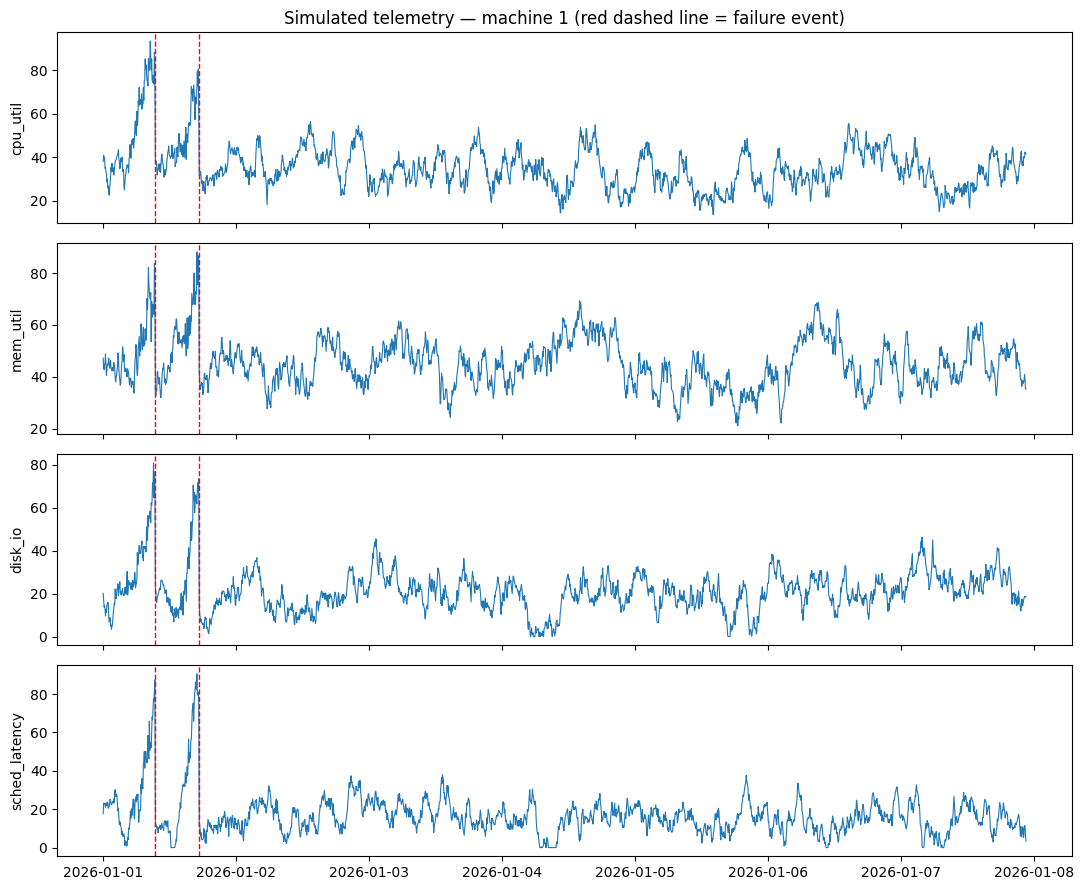

In [9]:
machine_with_failure = raw_df.loc[raw_df["failure_event"] == 1, "machine_id"]
example_machine = int(machine_with_failure.iloc[0]) if len(machine_with_failure) else 0

sub = raw_df[raw_df["machine_id"] == example_machine]
fail_times = sub.loc[sub["failure_event"] == 1, "timestamp"]

fig, axes = plt.subplots(len(sim_cfg.telemetry_cols), 1, figsize=(11, 9), sharex=True)
for ax, col in zip(axes, sim_cfg.telemetry_cols):
    ax.plot(sub["timestamp"], sub[col], linewidth=0.8)
    for ft in fail_times:
        ax.axvline(ft, color="red", linestyle="--", linewidth=1)
    ax.set_ylabel(col)
axes[0].set_title(f"Simulated telemetry — machine {example_machine} (red dashed line = failure event)")
plt.tight_layout()
plt.show()


## 4. Backward-Only Multi-Scale Sliding-Window Feature Extraction

Implements the equations from Section 4.3 of the paper, per telemetry stream $i$ and window length $W$:

$$\mu_{i,t}^{(W)} = \frac{1}{W}\sum_{k=0}^{W-1} x_{i,t-k}, \qquad
\sigma_{i,t}^{(W)} = \sqrt{\frac{1}{W}\sum_{k=0}^{W-1}\left(x_{i,t-k} - \mu_{i,t}^{(W)}\right)^2}$$

$$\text{Trend}_{i,t}^{(W)} = x_{i,t} - x_{i,t-W}, \qquad
\text{CV}_{i,t}^{(W)} = \frac{\sigma_{i,t}^{(W)}}{\mu_{i,t}^{(W)} + \epsilon}$$

**Key implementation rule:** every rolling computation for row `t` may reference rows `t-W+1 … t` and nothing later. This is achieved by grouping per `machine_id`, sorting by `timestamp`, and using pandas' default (right-aligned, backward-looking) `.rolling()` — never `center=True`. Rows with fewer than `W` prior samples (the start of each machine's trace) are dropped rather than padded, per the paper's stated policy.


In [10]:
def add_backward_window_features(
    df: pd.DataFrame,
    telemetry_cols: List[str],
    window_sizes: List[int],
    group_col: str = "machine_id",
    time_col: str = "timestamp",
    epsilon: float = 1e-6,
) -> pd.DataFrame:
    '''Backward-only, multi-scale rolling feature extraction (Section 4.3).

    For every (telemetry_col, window_size) pair, adds four columns:
      {col}_mean_W{W}, {col}_std_W{W}, {col}_trend_W{W}, {col}_cv_W{W}

    Guarantees (enforced structurally, not just by convention):
      - grouping by group_col prevents any window from crossing a machine boundary
      - sorting by time_col before rolling guarantees chronological order
      - pandas' default rolling window is right-aligned (backward-looking) and
        INCLUDES the current row, matching the k=0..W-1 summation in the paper
      - center=True is never used anywhere in this function
    '''
    out = df.sort_values([group_col, time_col]).copy()
    grouped = out.groupby(group_col, sort=False)

    for col in telemetry_cols:
        for W in window_sizes:
            roll = grouped[col].rolling(window=W, min_periods=W)
            mean_feat = roll.mean().reset_index(level=0, drop=True)
            std_feat = roll.std(ddof=0).reset_index(level=0, drop=True)

            # trend: x(t) - x(t-W), computed per group via a leakage-safe backward shift
            shifted = grouped[col].shift(W - 1)  # x_{t-(W-1)} aligns to x_{t-W} in the paper's 0-indexed window
            trend_feat = out[col] - shifted

            out[f"{col}_mean_W{W}"] = mean_feat
            out[f"{col}_std_W{W}"] = std_feat
            out[f"{col}_trend_W{W}"] = trend_feat
            out[f"{col}_cv_W{W}"] = std_feat / (mean_feat + epsilon)

    return out


feature_df = add_backward_window_features(
    raw_df,
    telemetry_cols=list(sim_cfg.telemetry_cols),
    window_sizes=list(feat_cfg.window_sizes),
)

n_before = len(feature_df)
feature_df = feature_df.dropna().reset_index(drop=True)
n_after = len(feature_df)
print(f"Rows before dropping insufficient-history rows: {n_before}")
print(f"Rows after (min_periods=W enforced per window scale): {n_after}")
print(f"Dropped {n_before - n_after} rows lacking full history for the largest window (W={max(feat_cfg.window_sizes)}).")
feature_df.head()


Rows before dropping insufficient-history rows: 50000
Rows after (min_periods=W enforced per window scale): 48525
Dropped 1475 rows lacking full history for the largest window (W=60).


,machine_id,timestamp,cpu_util,mem_util,disk_io,sched_latency,failure_event,cpu_util_mean_W5,cpu_util_std_W5,cpu_util_trend_W5,...,sched_latency_trend_W5,sched_latency_cv_W5,sched_latency_mean_W15,sched_latency_std_W15,sched_latency_trend_W15,sched_latency_cv_W15,sched_latency_mean_W60,sched_latency_std_W60,sched_latency_trend_W60,sched_latency_cv_W60
0,0,2026-01-01 04:55:00,39.131989,43.272702,24.031008,14.962261,0,37.355396,1.528355,2.923366,...,-1.620174,0.119618,14.168309,1.720181,1.874309,0.121410,10.855795,4.182974,-0.600531,0.385322
1,0,2026-01-01 05:00:00,34.718215,39.741555,24.441806,13.662319,0,37.057314,1.837102,-0.742121,...,-1.498822,0.091297,14.206600,1.702003,-1.713313,0.119804,10.824120,4.154308,-1.738976,0.383801
2,0,2026-01-01 05:05:00,33.895091,44.310377,26.878488,11.552873,0,36.744266,2.183302,-5.279581,...,-0.970392,0.094420,13.951749,1.791715,-2.469892,0.128422,10.759980,4.112644,-5.988466,0.382217
3,0,2026-01-01 05:10:00,34.357220,45.027015,24.904377,12.113890,0,35.780775,1.948516,-2.444141,...,0.051490,0.098057,13.824491,1.849025,-4.034295,0.133750,10.669523,4.021164,-6.817215,0.376883
4,0,2026-01-01 05:15:00,35.854914,45.974883,23.088139,13.505752,0,35.591486,1.885117,-3.277074,...,-1.456509,0.091803,13.648329,1.742028,-2.189276,0.127637,10.579100,3.893340,2.235758,0.368022


In [11]:
feature_cols = [c for c in feature_df.columns
                if c not in ["machine_id", "timestamp", "failure_event"]]
print(f"Total engineered features: {len(feature_cols)}")
print(f"({len(sim_cfg.telemetry_cols)} telemetry streams × {len(feat_cfg.window_sizes)} window scales × 4 statistics)")
feature_cols


Total engineered features: 52
(4 telemetry streams × 3 window scales × 4 statistics)


['cpu_util',
 'mem_util',
 'disk_io',
 'sched_latency',
 'cpu_util_mean_W5',
 'cpu_util_std_W5',
 'cpu_util_trend_W5',
 'cpu_util_cv_W5',
 'cpu_util_mean_W15',
 'cpu_util_std_W15',
 'cpu_util_trend_W15',
 'cpu_util_cv_W15',
 'cpu_util_mean_W60',
 'cpu_util_std_W60',
 'cpu_util_trend_W60',
 'cpu_util_cv_W60',
 'mem_util_mean_W5',
 'mem_util_std_W5',
 'mem_util_trend_W5',
 'mem_util_cv_W5',
 'mem_util_mean_W15',
 'mem_util_std_W15',
 'mem_util_trend_W15',
 'mem_util_cv_W15',
 'mem_util_mean_W60',
 'mem_util_std_W60',
 'mem_util_trend_W60',
 'mem_util_cv_W60',
 'disk_io_mean_W5',
 'disk_io_std_W5',
 'disk_io_trend_W5',
 'disk_io_cv_W5',
 'disk_io_mean_W15',
 'disk_io_std_W15',
 'disk_io_trend_W15',
 'disk_io_cv_W15',
 'disk_io_mean_W60',
 'disk_io_std_W60',
 'disk_io_trend_W60',
 'disk_io_cv_W60',
 'sched_latency_mean_W5',
 'sched_latency_std_W5',
 'sched_latency_trend_W5',
 'sched_latency_cv_W5',
 'sched_latency_mean_W15',
 'sched_latency_std_W15',
 'sched_latency_trend_W15',
 'sched_lat

## 5. Leakage Boundary Check (programmatic audit — feature-level only)

This is the feature-level slice of the full Leakage Audit Module described in Section 4.8 of the paper (the complete audit — including partition-level and validation-level checks — belongs to a later module, once splitting and cross-validation exist). Two independent checks are run here:

1. **Structural check:** for a random sample of rows, manually recompute each feature using *only* rows with `timestamp <= t` drawn directly from the raw data, and assert the result matches the pipeline's output exactly. This is a genuine recomputation, not a restatement of the pipeline's own logic.
2. **Counterexample check:** compute the same features using a deliberately leakage-prone **centered** window (`center=True`) and confirm it produces *different* values from the backward-only pipeline — this demonstrates the audit is actually sensitive to the leakage it's designed to catch, rather than trivially passing.


In [12]:
def leakage_boundary_check(raw: pd.DataFrame, features: pd.DataFrame, telemetry_cols, window_sizes,
                            group_col="machine_id", time_col="timestamp", n_samples=200, seed=RANDOM_SEED,
                            epsilon=1e-6) -> bool:
    '''Recomputes features for a random sample of rows directly from raw data,
    using only observations with timestamp <= t, and checks for an exact match
    against the pipeline's output. Returns True if no violation is found.
    '''
    check_rng = np.random.default_rng(seed)
    sample_idx = check_rng.choice(features.index, size=min(n_samples, len(features)), replace=False)
    violations = []

    raw_sorted = raw.sort_values([group_col, time_col])

    for idx in sample_idx:
        row = features.loc[idx]
        machine_id, t = row[group_col], row[time_col]
        history = raw_sorted[(raw_sorted[group_col] == machine_id) & (raw_sorted[time_col] <= t)]

        for col in telemetry_cols:
            for W in window_sizes:
                if len(history) < W:
                    continue
                window_vals = history[col].iloc[-W:].values  # last W obs with timestamp <= t
                expected_mean = window_vals.mean()
                expected_std = window_vals.std(ddof=0)
                expected_cv = expected_std / (expected_mean + epsilon)

                actual_mean = row[f"{col}_mean_W{W}"]
                actual_std = row[f"{col}_std_W{W}"]
                actual_cv = row[f"{col}_cv_W{W}"]

                if not np.isclose(expected_mean, actual_mean, atol=1e-8):
                    violations.append((idx, col, W, "mean", expected_mean, actual_mean))
                if not np.isclose(expected_std, actual_std, atol=1e-8):
                    violations.append((idx, col, W, "std", expected_std, actual_std))
                if not np.isclose(expected_cv, actual_cv, atol=1e-8):
                    violations.append((idx, col, W, "cv", expected_cv, actual_cv))

    if violations:
        print(f"LEAKAGE AUDIT FAILED: {len(violations)} violation(s) found.")
        for v in violations[:10]:
            print("  ", v)
        return False

    print(f"Leakage audit PASSED: {len(sample_idx)} sampled rows recomputed independently from raw data, "
          f"across {len(telemetry_cols)} telemetry streams and {len(window_sizes)} window scales — no discrepancy found.")
    return True


audit_passed = leakage_boundary_check(
    raw_df, feature_df,
    telemetry_cols=list(sim_cfg.telemetry_cols),
    window_sizes=list(feat_cfg.window_sizes),
)
assert audit_passed, "Pipeline halted: leakage boundary check failed (Section 4.8 policy — do not proceed to reporting)."


Leakage audit PASSED: 200 sampled rows recomputed independently from raw data, across 4 telemetry streams and 3 window scales — no discrepancy found.


In [13]:
# Counterexample: a deliberately leakage-prone CENTERED window, included only to demonstrate
# that the audit is sensitive to real leakage. This function is NOT part of the proposed pipeline
# and must never be used for actual feature extraction or model training.
def add_leaky_centered_features_FOR_ILLUSTRATION_ONLY(df, telemetry_cols, window_sizes,
                                                        group_col="machine_id", time_col="timestamp"):
    out = df.sort_values([group_col, time_col]).copy()
    grouped = out.groupby(group_col, sort=False)
    for col in telemetry_cols:
        for W in window_sizes:
            roll = grouped[col].rolling(window=W, center=True, min_periods=W)  # LEAKAGE: center=True
            out[f"{col}_mean_W{W}_LEAKY"] = roll.mean().reset_index(level=0, drop=True)
    return out

leaky_df = add_leaky_centered_features_FOR_ILLUSTRATION_ONLY(
    raw_df, list(sim_cfg.telemetry_cols), list(feat_cfg.window_sizes)
).dropna().reset_index(drop=True)

compare_col, W_example = "cpu_util", feat_cfg.window_sizes[0]
merged = feature_df.merge(
    leaky_df[["machine_id", "timestamp", f"{compare_col}_mean_W{W_example}_LEAKY"]],
    on=["machine_id", "timestamp"], how="inner",
)
n_differ = (~np.isclose(
    merged[f"{compare_col}_mean_W{W_example}"],
    merged[f"{compare_col}_mean_W{W_example}_LEAKY"],
    atol=1e-8,
)).sum()
pct_differ = 100 * n_differ / len(merged)
print(f"Backward-only vs. centered-window '{compare_col}' mean (W={W_example}) differ on "
      f"{n_differ}/{len(merged)} rows ({pct_differ:.1f}%).")
print("This confirms the leakage audit would correctly reject the centered-window variant "
      "as inconsistent with a strictly backward-only computation.")


Backward-only vs. centered-window 'cpu_util' mean (W=5) differ on 47793/47800 rows (100.0%).
This confirms the leakage audit would correctly reject the centered-window variant as inconsistent with a strictly backward-only computation.


### 5.1 Feature inspection near a failure event

Sanity-check that the extracted features actually rise ahead of a failure — this is what a downstream classifier (Module 3+) will learn to detect.

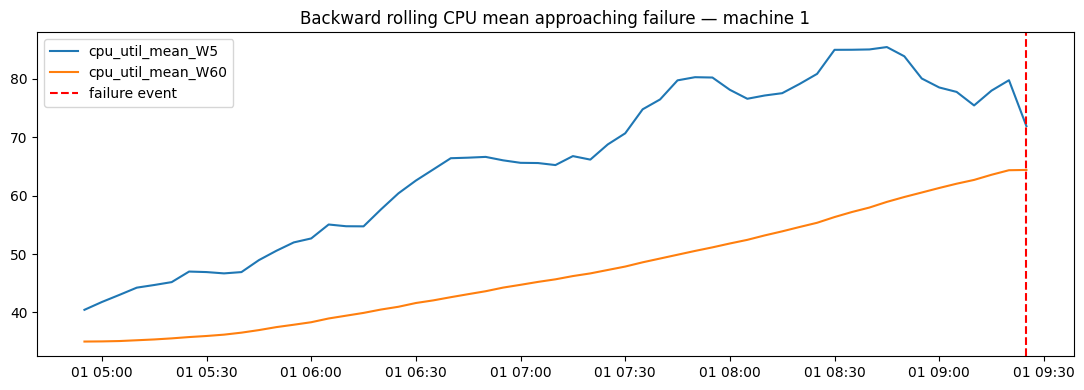

In [14]:
fail_row = feature_df[(feature_df["machine_id"] == example_machine) & (feature_df["failure_event"] == 1)]
if len(fail_row):
    fail_t = fail_row["timestamp"].iloc[0]
    window_start = fail_t - pd.Timedelta(minutes=sim_cfg.sampling_interval_minutes * 80)
    window_view = feature_df[
        (feature_df["machine_id"] == example_machine) &
        (feature_df["timestamp"] <= fail_t) &
        (feature_df["timestamp"] >= window_start)
    ]
    fig, ax = plt.subplots()
    ax.plot(window_view["timestamp"], window_view[f"cpu_util_mean_W{feat_cfg.window_sizes[0]}"], label=f"cpu_util_mean_W{feat_cfg.window_sizes[0]}")
    ax.plot(window_view["timestamp"], window_view[f"cpu_util_mean_W{feat_cfg.window_sizes[-1]}"], label=f"cpu_util_mean_W{feat_cfg.window_sizes[-1]}")
    ax.axvline(fail_t, color="red", linestyle="--", label="failure event")
    ax.set_title(f"Backward rolling CPU mean approaching failure — machine {example_machine}")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Machine {example_machine} has no failure event in this run; re-run Section 3 with a different seed if needed.")


## 6. Save Outputs

Persist both the raw simulated dataset and the engineered feature table, so Module 2 (leakage-safe forward-horizon labeling + chronological partitioning) can load them without re-running the simulation.


In [15]:
import os
os.makedirs("module1_outputs", exist_ok=True)

raw_df.to_parquet("module1_outputs/raw_simulated_telemetry.parquet", index=False)
feature_df.to_parquet("module1_outputs/backward_window_features.parquet", index=False)

print("Saved:")
print("  module1_outputs/raw_simulated_telemetry.parquet   ", raw_df.shape)
print("  module1_outputs/backward_window_features.parquet  ", feature_df.shape)


Saved:
  module1_outputs/raw_simulated_telemetry.parquet    (50000, 7)
  module1_outputs/backward_window_features.parquet   (48525, 55)


## 7. Summary & Handoff to Module 2

This notebook implemented:

- A configurable, schema-harmonization-compatible telemetry **simulator** (`simulate_dataset`) producing multi-machine CPU/memory/disk-I/O/scheduling-latency traces with realistic pre-failure degradation, standing in for the real Google/Alibaba/Azure harmonized extracts during pipeline development.
- **Backward-only, multi-scale sliding-window feature extraction** (`add_backward_window_features`) implementing the rolling mean, rolling standard deviation, first-difference trend, and coefficient-of-variation equations from Section 4.3, at `W ∈ {5, 15, 60}`.
- A **feature-level leakage boundary check** (`leakage_boundary_check`) that independently recomputes a random sample of features from raw data and verifies an exact match, plus a labeled counterexample showing the audit correctly flags a centered-window (leaky) alternative as inconsistent.

**Explicitly not implemented here (reserved for later modules), matching the M1 methodology's own component boundaries:**
- Forward-horizon failure labeling (Method 2 / Section 4.4)
- Chronological train/validation/test partitioning (Method 3 / Section 4.5)
- Forward-chaining hyperparameter search and XGBoost training (Methods 4 & 7 / Sections 4.6–4.7)
- The complete leakage audit module, including partition- and validation-level checks (Method 5 / Section 4.8)
- Random Forest / SVM baseline comparison (Section 5.6)

`module1_outputs/backward_window_features.parquet` is the input Module 2 will consume.
